# Text Classification and Sentiment Analysis with Transformers

This notebook demonstrates how to use pretrained Transformer models (BERT) for text classification, focusing on **sentiment analysis** as a supervised learning task.

**Learning objectives:**
- Understand text classification as a supervised problem.
- Use a pretrained pipeline for quick sentiment inference.
- Understand how tokenization works in practice.
- Fine-tune BERT on the IMDB dataset for binary sentiment classification.
- Evaluate the model and test on custom sentences.

**Dependencies:** `torch`, `transformers`, `datasets` (all from HuggingFace/PyTorch — no `torchtext` needed).

To install: `pip install torch transformers datasets`

## 1. Setup

In [1]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import load_dataset

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

2026-07-21 16:18:43.657857: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-21 16:18:44.761744: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-21 16:18:47.323107: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


PyTorch version: 2.10.0+cu128
Using device: cuda


## 2. Quick inference with a pretrained pipeline

HuggingFace provides ready-to-use **pipelines** that wrap a pretrained model + tokenizer. This is the fastest way to get predictions without any training.

The model below (`distilbert-base-uncased-finetuned-sst-2-english`) is a DistilBERT model already fine-tuned on the SST-2 sentiment dataset.

In [2]:
# Load a pretrained sentiment analysis pipeline
sentiment_pipeline = pipeline(
    "sentiment-analysis", 
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device
)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [3]:
# Test on a few sentences
sentences = [
    "I absolutely loved this movie, it was fantastic!",
    "The food was terrible and the service was slow.",
    "The weather is okay today.",
    "This course on deep learning is very interesting.",
]

for sentence in sentences:
    result = sentiment_pipeline(sentence)[0]
    print(f"Text: {sentence}")
    print(f"  -> {result['label']} (confidence: {result['score']:.4f})")
    print()

Text: I absolutely loved this movie, it was fantastic!
  -> POSITIVE (confidence: 0.9999)

Text: The food was terrible and the service was slow.
  -> NEGATIVE (confidence: 0.9998)

Text: The weather is okay today.
  -> POSITIVE (confidence: 0.9998)

Text: This course on deep learning is very interesting.
  -> POSITIVE (confidence: 0.9998)



The pipeline handles everything internally: tokenization, feeding through the model, and converting logits to labels. But to understand what's happening and to train our own model, we need to look under the hood.

## 2b. Extracting word embeddings from a pretrained model

Before fine-tuning, it is useful to understand what a pretrained Transformer produces. Given a sentence, the encoder outputs a **contextualized embedding** for each token. These embeddings can be used directly for tasks like similarity matching, clustering, or as features for classical classifiers.

Let's extract embeddings from a pretrained BERT model (before any fine-tuning) to see what they look like.

In [4]:
from transformers import AutoModel

# Load the base BERT model (no classification head -- just the encoder)
bert_model = AutoModel.from_pretrained("bert-base-uncased")
bert_model.eval()
bert_model.to(device)

# Load the tokenizer (same one we will use throughout)
embedding_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenize sentences with different meanings of "bank"
sentences = [
    "I deposited money at the bank.",
    "We sat on the river bank and watched the sunset.",
    "The bank approved my loan application.",
]

print("Extracting contextualized embeddings for each sentence...")
print()

for sentence in sentences:
    inputs = embedding_tokenizer(sentence, return_tensors="pt", padding=True, truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = bert_model(**inputs)
    
    # outputs.last_hidden_state: (batch_size, seq_length, hidden_dim)
    hidden_states = outputs.last_hidden_state
    
    tokens = embedding_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    print(f"Sentence: \'{sentence}\'")
    print(f"  Tokens: {tokens}")
    print(f"  Hidden state shape: {hidden_states.shape}  (1 sentence, {hidden_states.shape[1]} tokens, {hidden_states.shape[2]} dims)")
    
    # The [CLS] token (index 0) serves as the sentence-level representation
    cls_emb = hidden_states[0, 0, :]
    print(f"  [CLS] embedding (first 8 dims): {cls_emb[:8].cpu().numpy().round(4)}")
    print()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Extracting contextualized embeddings for each sentence...

Sentence: 'I deposited money at the bank.'
  Tokens: ['[CLS]', 'i', 'deposited', 'money', 'at', 'the', 'bank', '.', '[SEP]']
  Hidden state shape: torch.Size([1, 9, 768])  (1 sentence, 9 tokens, 768 dims)
  [CLS] embedding (first 8 dims): [ 0.1662  0.3304 -0.1147  0.0067 -0.2003  0.1189  0.1173  0.5774]

Sentence: 'We sat on the river bank and watched the sunset.'
  Tokens: ['[CLS]', 'we', 'sat', 'on', 'the', 'river', 'bank', 'and', 'watched', 'the', 'sunset', '.', '[SEP]']
  Hidden state shape: torch.Size([1, 13, 768])  (1 sentence, 13 tokens, 768 dims)
  [CLS] embedding (first 8 dims): [ 0.2836 -0.2223 -0.2759 -0.0451 -0.4657 -0.4618  0.2986  0.9102]

Sentence: 'The bank approved my loan application.'
  Tokens: ['[CLS]', 'the', 'bank', 'approved', 'my', 'loan', 'application', '.', '[SEP]']
  Hidden state shape: torch.Size([1, 9, 768])  (1 sentence, 9 tokens, 768 dims)
  [CLS] embedding (first 8 dims): [ 0.1868 -0.055  -0.172 

In [5]:
# Demonstrate that "bank" gets DIFFERENT embeddings depending on context
# This is the key advantage of Transformers over context-free embeddings (word2vec)

def get_token_embedding(sentence, target_word, model, tok, dev):
    """Get the embedding of a specific word in context."""
    inputs = tok(sentence, return_tensors="pt", padding=True, truncation=True)
    inputs = {k: v.to(dev) for k, v in inputs.items()}
    tokens = tok.convert_ids_to_tokens(inputs["input_ids"][0])
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Find the target token index
    for i, t in enumerate(tokens):
        if t == target_word:
            return outputs.last_hidden_state[0, i, :].cpu().numpy()
    
    print(f"  Warning: \'{target_word}\' not found in tokens {tokens}")
    return None

emb_financial = get_token_embedding("I deposited money at the bank.", "bank", bert_model, embedding_tokenizer, device)
emb_river     = get_token_embedding("We sat on the river bank and watched the sunset.", "bank", bert_model, embedding_tokenizer, device)
emb_loan      = get_token_embedding("The bank approved my loan application.", "bank", bert_model, embedding_tokenizer, device)

# Compute cosine similarities
from numpy.linalg import norm

def cosine_sim(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

print("Cosine similarity between \'bank\' embeddings in different contexts:")
print(f"  financial vs. loan:  {cosine_sim(emb_financial, emb_loan):.4f}  (similar meaning)")
print(f"  financial vs. river: {cosine_sim(emb_financial, emb_river):.4f}  (different meaning)")
print(f"  loan vs. river:      {cosine_sim(emb_loan, emb_river):.4f}  (different meaning)")
print()
print("The same word \'bank\' gets different embeddings depending on context.")
print("This is what makes Transformer encoders powerful for NLP tasks.")

Cosine similarity between 'bank' embeddings in different contexts:
  financial vs. loan:  0.8324  (similar meaning)
  financial vs. river: 0.5029  (different meaning)
  loan vs. river:      0.4376  (different meaning)

The same word 'bank' gets different embeddings depending on context.
This is what makes Transformer encoders powerful for NLP tasks.


In [6]:
# Clean up -- we will load a fresh model with a classification head for fine-tuning later
del bert_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 3. Understanding tokenization

Before any text enters a Transformer, it must be converted into **token IDs**. BERT uses **WordPiece** tokenization, which splits words into subword units.

Key concepts:
- **[CLS]**: Classification token prepended to every input. Its final embedding is used as the sentence representation for classification.
- **[SEP]**: Separator token marking the end of a sentence (or between sentence pairs).
- **[PAD]**: Padding token to make all sequences the same length in a batch.
- **Attention mask**: Indicates which tokens are real (1) and which are padding (0).

In [7]:
# Load the BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenize a sentence and inspect the result
sentence = "Deep learning is transforming natural language processing."
tokens = tokenizer(sentence, padding="max_length", max_length=20, truncation=True, return_tensors="pt")

print(f"Original text:  '{sentence}'")
print(f"Token IDs:      {tokens['input_ids'][0].tolist()}")
print(f"Attention mask: {tokens['attention_mask'][0].tolist()}")
print()

# Decode back to see the tokens
token_list = tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])
print(f"Tokens: {token_list}")
print()
print("Notice:")
print("- [CLS] at the start, [SEP] at the end, [PAD] to fill max_length")
print("- 'transforming' is split into subwords (## prefix marks continuation tokens)")

Original text:  'Deep learning is transforming natural language processing.'
Token IDs:      [101, 2784, 4083, 2003, 17903, 3019, 2653, 6364, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Tokens: ['[CLS]', 'deep', 'learning', 'is', 'transforming', 'natural', 'language', 'processing', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

Notice:
- [CLS] at the start, [SEP] at the end, [PAD] to fill max_length
- 'transforming' is split into subwords (## prefix marks continuation tokens)


## 4. Loading and preparing the IMDB dataset

The [IMDB dataset](https://huggingface.co/datasets/imdb) contains 50,000 movie reviews labeled as **positive** (1) or **negative** (0) — a standard benchmark for binary sentiment classification.

We load it directly from HuggingFace's `datasets` library (not `torchtext`, which is deprecated).

In [8]:
# Load the IMDB dataset from HuggingFace
dataset = load_dataset("imdb")

print(f"Train: {len(dataset['train'])} samples")
print(f"Test:  {len(dataset['test'])} samples")
print()

# Inspect a sample
sample = dataset["train"][0]
print(f"Label: {sample['label']} ({'positive' if sample['label'] == 1 else 'negative'})")
print(f"Text (first 300 chars): {sample['text'][:300]}...")

README.md: 0.00B [00:00, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train: 25000 samples
Test:  25000 samples

Label: 0 (negative)
Text (first 300 chars): I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h...


For efficiency in this notebook, we use a **subset** of the data. In practice, you would use the full dataset for better results.

In [9]:
# Use a smaller subset for faster training in class
# Full dataset (25000 train + 25000 test) takes hours on CPU.
train_subset = dataset["train"].shuffle(seed=42).select(range(2000))
test_full    = dataset["test"].shuffle(seed=42)
val_subset   = test_full.select(range(500))
test_subset  = test_full.select(range(500, 1000))

print(f"Training:   {len(train_subset)} samples")
print(f"Validation: {len(val_subset)} samples")
print(f"Test:       {len(test_subset)} samples")

Training:   2000 samples
Validation: 500 samples
Test:       500 samples


In [10]:
# Tokenize all splits
# max_length=256 is a trade-off between capturing enough context and speed.
# BERT supports up to 512 tokens.

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

train_dataset = train_subset.map(tokenize_function, batched=True)
val_dataset   = val_subset.map(tokenize_function, batched=True)
test_dataset  = test_subset.map(tokenize_function, batched=True)

print("Tokenization complete.")
print(f"Features: {train_dataset.column_names}")

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenization complete.
Features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']


## 5. Fine-tuning BERT for sentiment classification

We load `bert-base-uncased` with a classification head (`AutoModelForSequenceClassification`). This adds a single dense layer on top of the **[CLS]** token embedding, exactly as discussed in the lecture.

The backbone is pretrained — we **fine-tune** all parameters on our task-specific data with a small learning rate for a few epochs.

In [11]:
# Load BERT with a classification head (2 labels: positive/negative)
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", 
    num_labels=2
)
model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters:     109,483,778
Trainable parameters: 109,483,778


In [12]:
# Accuracy metric — computed manually (no extra dependencies needed)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = (predictions == labels).mean()
    return {"accuracy": accuracy}

In [13]:
# Training arguments
# 3 epochs is standard for BERT fine-tuning (more risks overfitting)
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    learning_rate=2e-5,       # standard for BERT fine-tuning
    eval_strategy="epoch",    # evaluate after each epoch
    save_strategy="epoch",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

In [14]:
# Create Trainer and train
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.544400,0.312286,0.880000
2,0.262300,0.306394,0.878000
3,0.155100,0.321956,0.886000


TrainOutput(global_step=375, training_loss=0.3349287255605062, metrics={'train_runtime': 108.6357, 'train_samples_per_second': 55.23, 'train_steps_per_second': 3.452, 'total_flos': 789333166080000.0, 'train_loss': 0.3349287255605062, 'epoch': 3.0})

## 6. Evaluation on the test set

After training, we evaluate on the held-out test set to measure generalization.

In [15]:
# Evaluate on the test set
results = trainer.evaluate(test_dataset)
print(f"Test loss:     {results['eval_loss']:.4f}")
print(f"Test accuracy: {results['eval_accuracy']:.4f}")

Test loss:     0.3991
Test accuracy: 0.8640


## 7. Testing on custom sentences

Now we can use our fine-tuned model to classify arbitrary text. We tokenize the input, feed it through the model, and interpret the logits.

In [16]:
def predict_sentiment(text, model, tokenizer, device):
    """Predict sentiment for a single text string."""
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    probabilities = torch.softmax(outputs.logits, dim=-1)
    predicted_class = torch.argmax(probabilities, dim=-1).item()
    confidence = probabilities[0, predicted_class].item()
    
    label = "POSITIVE" if predicted_class == 1 else "NEGATIVE"
    return label, confidence

# Test on custom sentences
test_sentences = [
    "This movie was a complete waste of time. Terrible acting and boring plot.",
    "An absolutely brilliant film with outstanding performances!",
    "The movie was okay, nothing special but not bad either.",
    "I could not stop watching. One of the best experiences I have ever had!",
    "Disappointing sequel that fails to capture the magic of the original.",
]

print("Predictions from our fine-tuned BERT model:")
print("=" * 60)
for sentence in test_sentences:
    label, confidence = predict_sentiment(sentence, model, tokenizer, device)
    print(f"Text: {sentence}")
    print(f"  -> {label} (confidence: {confidence:.4f})")
    print()

Predictions from our fine-tuned BERT model:
Text: This movie was a complete waste of time. Terrible acting and boring plot.
  -> NEGATIVE (confidence: 0.9807)

Text: An absolutely brilliant film with outstanding performances!
  -> POSITIVE (confidence: 0.9884)

Text: The movie was okay, nothing special but not bad either.
  -> NEGATIVE (confidence: 0.5657)

Text: I could not stop watching. One of the best experiences I have ever had!
  -> POSITIVE (confidence: 0.9867)

Text: Disappointing sequel that fails to capture the magic of the original.
  -> NEGATIVE (confidence: 0.9244)



## 8. Inspecting the [CLS] embedding

As discussed in the lecture, the **[CLS]** token embedding after the last encoder layer serves as the sentence representation for classification. Let's visualize how positive and negative sentences are separated in this embedding space.

Extracting [CLS] embeddings for 100 test samples...


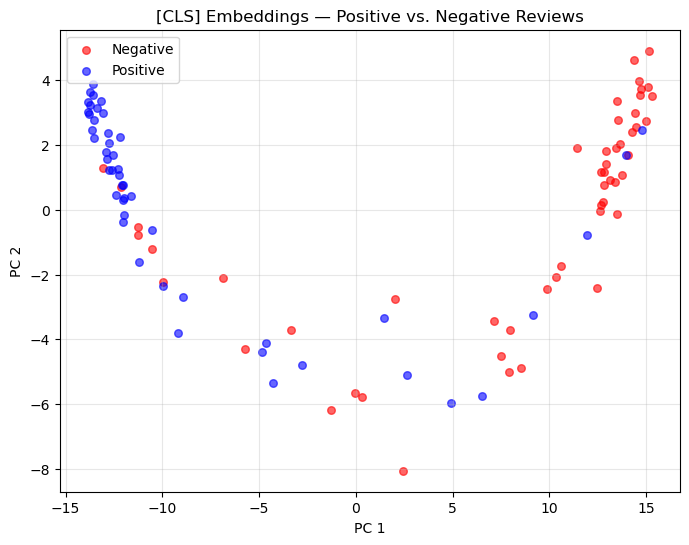

After fine-tuning, positive and negative reviews should form separable clusters.


In [17]:
from sklearn.decomposition import PCA

def get_cls_embedding(text, model, tokenizer, device):
    """Extract the [CLS] embedding from the last hidden layer."""
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    
    # [CLS] is the first token (index 0) of the last hidden state
    cls_embedding = outputs.hidden_states[-1][0, 0, :].cpu().numpy()
    return cls_embedding

# Collect [CLS] embeddings for test samples
print("Extracting [CLS] embeddings for 100 test samples...")
sample_texts = [test_subset[i]["text"][:512] for i in range(100)]
sample_labels = [test_subset[i]["label"] for i in range(100)]

embeddings = np.array([get_cls_embedding(t, model, tokenizer, device) for t in sample_texts])
labels = np.array(sample_labels)

# Project to 2D with PCA
pca = PCA(n_components=2)
projected = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
for label, name, color in [(0, "Negative", "red"), (1, "Positive", "blue")]:
    mask = labels == label
    plt.scatter(projected[mask, 0], projected[mask, 1], c=color, label=name, alpha=0.6, s=30)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("[CLS] Embeddings — Positive vs. Negative Reviews")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("After fine-tuning, positive and negative reviews should form separable clusters.")

## Key takeaways

- **Text classification** is a supervised task: given a text input, predict a discrete label (e.g., positive/negative).
- **Sentiment analysis** is a specific case of text classification where labels represent opinions or emotions.
- **Pretrained pipelines** (HuggingFace) allow quick inference with zero training.
- **Fine-tuning BERT** involves: loading a pretrained model with a classification head on top of the [CLS] embedding, tokenizing the dataset, and training for 2–3 epochs with a small learning rate (~2e-5).
- The **[CLS] token embedding** serves as the sentence-level representation for classification.
- The standard training loop (forward, loss, backward, update) is handled by the HuggingFace `Trainer`, but the same principles from previous lectures apply.

**Exercises:**
- Try fine-tuning with the full IMDB dataset (25,000 training samples). How much does accuracy improve?
- Try a different pretrained model (e.g., `distilbert-base-uncased`, `roberta-base`). Compare speed and accuracy.
- Try freezing the BERT backbone (`for param in model.bert.parameters(): param.requires_grad = False`) and training only the classification head. How does this affect results?
- Modify the code to perform multi-class classification on the AG News dataset: `load_dataset("ag_news")` with 4 categories (World, Sports, Business, Sci/Tech).